# 94 — Assign nodal events to Geode stack metadata

This notebook joins the individual nodal detections from notebook 93 to the authoritative Geode stack windows from notebook 92. Time-window containment is the primary association rule. The nodal source-position estimate is retained as quality-control information, but it is never used to reject an otherwise unique Geode time-window match; this is essential for sources beyond the receiver aperture.

The notebook creates/replaces only its own SQLite tables:

- `geode_nodal_event_match_candidates`: every time-window candidate, including overlap diagnostics
- `geode_nodal_event_matches`: at most one selected Geode assignment per nodal event
- `geode_nodal_stack_match_summary`: stack-level assignment summary
- `geode_nodal_unmatched_stacks`: timed Geode stacks with no accepted nodal assignment
- `nodal_event_catalog`: every notebook-93 nodal detection, whether assigned or unassigned

Waveform similarity is evaluated later by notebook 95. CSV position columns are rounded to 0.01 m for honest presentation; SQLite retains computational precision.

## 1. Configuration

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"
OUT_ROOT = PROJECT_ROOT / "94_nodal_geode_match_exports"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Set one survey for focused testing, or None for the complete catalog.
TARGET_SURVEY = None

TIME_MARGIN_BEFORE_S = 0.0
TIME_MARGIN_AFTER_S = 0.0
POSITION_GOOD_RESIDUAL_M = 3.0
POSITION_REVIEW_RESIDUAL_M = 4.0
POSITION_EXPORT_DECIMALS = 2
WRITE_TABLES = True

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)
print("TARGET_SURVEY:", TARGET_SURVEY)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/94_nodal_geode_match_exports
TARGET_SURVEY: None


## 2. Database safety preflight

In [2]:
if not CATALOG_DB.exists():
    raise FileNotFoundError(f"Catalog database not found: {CATALOG_DB}\nRun 90_*, 92_*, and 93_* first.")

REQUIRED_INPUT_TABLES = [
    "shot_events",
    "shot_gather_files",
    "trace_index",
    "geode_events",
    "geode_time_models",
    "nodal_source_estimates",
]
NOTEBOOK_94_TABLES = [
    "geode_nodal_event_match_candidates",
    "geode_nodal_event_matches",
    "geode_nodal_stack_match_summary",
    "geode_nodal_unmatched_stacks",
    "nodal_event_catalog",
]

with sqlite3.connect(CATALOG_DB) as conn:
    existing_tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
    )["name"].tolist()

missing = [name for name in REQUIRED_INPUT_TABLES if name not in existing_tables]
if missing:
    raise RuntimeError(f"Catalog exists, but required input tables are missing: {missing}")

print("Input catalog checked:", CATALOG_DB)
print("94 will only create/replace:", NOTEBOOK_94_TABLES)

Input catalog checked: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
94 will only create/replace: ['geode_nodal_event_match_candidates', 'geode_nodal_event_matches', 'geode_nodal_stack_match_summary', 'geode_nodal_unmatched_stacks', 'nodal_event_catalog']


## 3. Load and normalize catalog tables

In [3]:
with sqlite3.connect(CATALOG_DB) as conn:
    geode_events = pd.read_sql("SELECT * FROM geode_events", conn)
    nodal_est = pd.read_sql("SELECT * FROM nodal_source_estimates", conn)
    nodal_trace_index = pd.read_sql(
        "SELECT event_id, receiver_x_m FROM trace_index WHERE instrument_system='nodal'", conn
    )

for col in ["stack_start_utc", "stack_end_utc", "geode_final_trigger_time_utc"]:
    geode_events[col.replace("_utc", "_dt")] = pd.to_datetime(
        geode_events.get(col), errors="coerce", utc=True
    )

for col in [
    "source_x_m", "file_no", "n_stack_shots",
    "receiver_first_m", "receiver_last_m",
]:
    geode_events[col] = pd.to_numeric(geode_events.get(col), errors="coerce")

nodal_trace_index["receiver_x_m"] = pd.to_numeric(
    nodal_trace_index["receiver_x_m"], errors="coerce"
)
nodal_apertures = (
    nodal_trace_index.dropna(subset=["receiver_x_m"])
    .groupby("event_id", as_index=False)
    .agg(
        nodal_receiver_first_m=("receiver_x_m", "min"),
        nodal_receiver_last_m=("receiver_x_m", "max"),
    )
)
nodal_est = nodal_est.merge(nodal_apertures, on="event_id", how="left", validate="one_to_one")

nodal_est["event_time_dt"] = pd.to_datetime(
    nodal_est.get("event_time_utc"), errors="coerce", utc=True
)
for col in ["estimated_source_x_m", "energy_x_m"]:
    nodal_est[col] = pd.to_numeric(nodal_est.get(col), errors="coerce")

geode_use = geode_events.dropna(
    subset=["stack_start_dt", "stack_end_dt", "source_x_m"]
).copy()
nodal_use = nodal_est.dropna(subset=["event_time_dt"]).copy()

if TARGET_SURVEY is not None:
    geode_use = geode_use[geode_use["survey"].astype(str).eq(TARGET_SURVEY)].copy()

print("geode_events:", len(geode_events), "usable timed stacks:", len(geode_use))
print("nodal_source_estimates:", len(nodal_est), "with usable event time:", len(nodal_use))
display(geode_use.groupby(["survey", "line"], dropna=False).size().reset_index(name="n_geode_stacks"))
display(nodal_use.groupby("timewindow_label", dropna=False).size().reset_index(name="n_nodal_events"))

geode_events: 242 usable timed stacks: 236
nodal_source_estimates: 3436 with usable event time: 3431


,survey,line,n_geode_stacks
0,T1_1m_refraction,T1,42
1,T1_2m_refraction,T1,42
2,T1_streamer_masw,T1,83
3,T3_1m_refraction,T3,39
4,T4_1m_refraction,T4,30


,timewindow_label,n_nodal_events
0,T1_N1_Streamer,532
1,T1_N2_Nodal1,1374
2,T1_N2_Nodal2,81
3,T1_N2_Refraction1m,429
4,T1_N2_Refraction2m,450
5,T1_N3_Nodal3,43
6,T3_N4_Refraction1am,522


## 4. Association and position-QC rules

In [4]:
def finite_number(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def source_geometry_class(source_x_m, receiver_first_m, receiver_last_m):
    source_x_m = finite_number(source_x_m)
    receiver_first_m = finite_number(receiver_first_m)
    receiver_last_m = finite_number(receiver_last_m)
    if not np.isfinite(source_x_m) or not np.isfinite(receiver_first_m) or not np.isfinite(receiver_last_m):
        return "unknown_aperture"
    aperture_min = min(receiver_first_m, receiver_last_m)
    aperture_max = max(receiver_first_m, receiver_last_m)
    if source_x_m < aperture_min:
        return "off_end_low"
    if source_x_m > aperture_max:
        return "off_end_high"
    return "inside_aperture"


def position_qc_status(source_geometry, source_x_residual_m):
    if str(source_geometry).startswith("off_end_"):
        return "not_applicable_off_end"
    residual = finite_number(source_x_residual_m)
    if not np.isfinite(residual):
        return "review_no_nodal_estimate"
    if abs(residual) <= POSITION_GOOD_RESIDUAL_M:
        return "consistent_with_geode"
    if abs(residual) <= POSITION_REVIEW_RESIDUAL_M:
        return "review_borderline_residual"
    return "review_large_residual"


def assignment_rank_score(window_center_offset_s, source_geometry, source_x_residual_m):
    # Time is primary. Position is only a small tie-breaker for overlapping windows
    # when the truth source lies inside the receiver aperture.
    score = -abs(finite_number(window_center_offset_s))
    residual = finite_number(source_x_residual_m)
    if source_geometry == "inside_aperture" and np.isfinite(residual):
        score -= 0.01 * abs(residual)
    return float(score)

## 5. Build and resolve Geode time-window candidates

In [5]:
candidate_rows = []

for _, geode in geode_use.iterrows():
    start = geode["stack_start_dt"] - pd.to_timedelta(TIME_MARGIN_BEFORE_S, unit="s")
    end = geode["stack_end_dt"] + pd.to_timedelta(TIME_MARGIN_AFTER_S, unit="s")
    center = start + (end - start) / 2
    source_truth = float(geode["source_x_m"])
    candidates = nodal_use
    expected_window = geode.get("nodal_timewindow_label")
    if isinstance(expected_window, str) and expected_window and expected_window.lower() not in {"none", "nan"}:
        candidates = candidates[candidates["timewindow_label"].astype(str).eq(expected_window)]

    expected_line = geode.get("line")
    if isinstance(expected_line, str) and expected_line and "line" in candidates.columns:
        candidates = candidates[candidates["line"].astype(str).eq(expected_line)]

    candidates = candidates[
        candidates["event_time_dt"].between(start, end, inclusive="both")
    ].copy()

    for _, nodal in candidates.iterrows():
        estimated_x = finite_number(nodal.get("estimated_source_x_m"))
        nodal_receiver_first = finite_number(nodal.get("nodal_receiver_first_m"))
        nodal_receiver_last = finite_number(nodal.get("nodal_receiver_last_m"))
        geometry_class = source_geometry_class(
            source_truth, nodal_receiver_first, nodal_receiver_last
        )
        residual = estimated_x - source_truth if np.isfinite(estimated_x) else np.nan
        abs_residual = abs(residual) if np.isfinite(residual) else np.nan
        final_dt = geode.get("geode_final_trigger_time_dt", pd.NaT)
        time_from_final_s = (
            (nodal["event_time_dt"] - final_dt).total_seconds()
            if pd.notna(final_dt) else np.nan
        )
        time_since_start_s = (nodal["event_time_dt"] - start).total_seconds()
        center_offset_s = (nodal["event_time_dt"] - center).total_seconds()
        position_status = position_qc_status(geometry_class, residual)

        candidate_rows.append({
            "geode_event_id": geode["geode_event_id"],
            "geode_survey": geode.get("survey"),
            "line": geode.get("line"),
            "file_no": int(geode["file_no"]) if np.isfinite(geode["file_no"]) else None,
            "source_type": geode.get("source_type"),
            "n_stack_shots": int(geode["n_stack_shots"]) if np.isfinite(geode["n_stack_shots"]) else None,
            "source_x_truth_m": source_truth,
            "nodal_receiver_first_m": nodal_receiver_first,
            "nodal_receiver_last_m": nodal_receiver_last,
            "source_geometry_class": geometry_class,
            "geode_final_trigger_time_utc": geode.get("geode_final_trigger_time_utc"),
            "stack_start_utc": geode.get("stack_start_utc"),
            "stack_end_utc": geode.get("stack_end_utc"),
            "geode_clock_correction_s": geode.get("geode_clock_correction_s"),
            "geode_file_time_meaning": geode.get("geode_file_time_meaning"),
            "nodal_event_id": nodal["event_id"],
            "nodal_timewindow_label": nodal.get("timewindow_label"),
            "nodal_event_time_utc": nodal.get("event_time_utc"),
            "nodal_event_time_method": nodal.get("event_time_method"),
            "estimated_source_x_m": estimated_x,
            "energy_x_m": finite_number(nodal.get("energy_x_m")),
            "source_x_method": nodal.get("source_x_method"),
            "source_x_residual_m": residual,
            "abs_source_x_residual_m": abs_residual,
            "position_qc_status": position_status,
            "time_from_final_trigger_s": time_from_final_s,
            "time_since_stack_start_s": time_since_start_s,
            "window_center_offset_s": center_offset_s,
            "match_score": assignment_rank_score(center_offset_s, geometry_class, residual),
            "mseed_path": nodal.get("mseed_path"),
            "top_energy_receivers_json": nodal.get("top_energy_receivers_json"),
        })

match_candidates = pd.DataFrame(candidate_rows)

if len(match_candidates):
    match_candidates["assignment_candidate_count"] = (
        match_candidates.groupby("nodal_event_id")["geode_event_id"].transform("nunique")
    )
    match_candidates = match_candidates.sort_values(
        ["nodal_event_id", "match_score", "geode_event_id"],
        ascending=[True, False, True],
    ).reset_index(drop=True)
    match_candidates["selected_assignment"] = ~match_candidates.duplicated("nodal_event_id")
    matches = match_candidates[match_candidates["selected_assignment"]].copy()
    unique_window = matches["assignment_candidate_count"].eq(1)
    matches["match_status"] = np.where(unique_window, "accepted_auto", "review_time_window_overlap")
    matches["accepted"] = unique_window
    matches["assignment_status"] = np.where(
        unique_window, "assigned_geode_time_window", "review_time_window_overlap"
    )
    matches["assignment_confidence"] = np.where(unique_window, "high", "review")
    matches["source_position_basis"] = np.where(unique_window, "geode_truth", "unresolved_overlap")
    matches["adopted_source_x_m"] = np.where(unique_window, matches["source_x_truth_m"], np.nan)
    matches["waveform_qc_status"] = np.where(
        unique_window, "pending_not_run_by_94", "not_ready_overlap_review"
    )
    matches["final_event_status"] = np.where(
        unique_window, "candidate_for_waveform_qc", "review_assignment"
    )
else:
    match_candidates = pd.DataFrame(columns=["nodal_event_id", "geode_event_id", "selected_assignment"])
    matches = pd.DataFrame(columns=[
        "nodal_event_id", "geode_event_id", "match_status", "accepted",
        "assignment_status", "assignment_confidence", "source_position_basis",
        "adopted_source_x_m", "waveform_qc_status", "final_event_status",
    ])

print("Time-window candidate rows:", len(match_candidates))
print("Selected event assignments:", len(matches))
if len(matches):
    display(matches["match_status"].value_counts(dropna=False))
    display(matches["position_qc_status"].value_counts(dropna=False))

Time-window candidate rows: 966
Selected event assignments: 966


match_status
accepted_auto    966
Name: count, dtype: int64

position_qc_status
consistent_with_geode         841
not_applicable_off_end        104
review_borderline_residual     14
review_large_residual           7
Name: count, dtype: int64

## 6. Build the complete nodal event catalog

In [6]:
event_catalog = nodal_est.rename(columns={
    "event_id": "nodal_event_id",
    "timewindow_label": "nodal_timewindow_label",
    "event_time_utc": "nodal_event_time_utc",
    "event_time_method": "nodal_event_time_method",
}).drop(columns=["event_time_dt"], errors="ignore").copy()

assignment_columns = [
    "nodal_event_id", "geode_event_id", "geode_survey", "file_no",
    "source_type", "n_stack_shots", "source_x_truth_m",
    "adopted_source_x_m", "source_position_basis",
    "source_geometry_class",
    "source_x_residual_m", "abs_source_x_residual_m", "position_qc_status",
    "geode_final_trigger_time_utc", "stack_start_utc", "stack_end_utc",
    "time_from_final_trigger_s", "time_since_stack_start_s",
    "assignment_candidate_count", "match_score", "match_status", "accepted",
    "assignment_status", "assignment_confidence", "waveform_qc_status",
    "final_event_status",
]
assignment_columns = [column for column in assignment_columns if column in matches.columns]
event_catalog = event_catalog.merge(
    matches[assignment_columns], on="nodal_event_id", how="left", validate="one_to_one"
)

event_catalog["accepted"] = event_catalog["accepted"].fillna(False).astype(bool)
event_catalog["assignment_candidate_count"] = (
    pd.to_numeric(event_catalog["assignment_candidate_count"], errors="coerce").fillna(0).astype(int)
)
unassigned = event_catalog["geode_event_id"].isna()
event_catalog.loc[unassigned, "assignment_status"] = "unassigned_no_geode_time_window"
event_catalog.loc[unassigned, "assignment_confidence"] = "unassigned"
event_catalog.loc[unassigned, "source_position_basis"] = "nodal_estimate_only"
event_catalog.loc[unassigned, "position_qc_status"] = "not_applicable_no_geode_truth"
event_catalog.loc[unassigned, "waveform_qc_status"] = "not_run_unassigned"
event_catalog.loc[unassigned, "final_event_status"] = "unassigned"

event_catalog = event_catalog.sort_values(
    ["nodal_timewindow_label", "nodal_event_time_utc", "nodal_event_id"],
    na_position="last",
).reset_index(drop=True)

assert len(event_catalog) == len(nodal_est)
assert event_catalog["nodal_event_id"].is_unique
assert matches["nodal_event_id"].is_unique

print("Complete nodal event catalog rows:", len(event_catalog))
display(event_catalog["assignment_status"].value_counts(dropna=False))
display(event_catalog.head())

Complete nodal event catalog rows: 3436


assignment_status
unassigned_no_geode_time_window    2470
assigned_geode_time_window          966
Name: count, dtype: int64

,nodal_event_id,line,nodal_timewindow_label,geometry_id,nodal_event_time_utc,nodal_event_time_method,estimated_source_x_m,source_x_method,energy_x_m,component,...,time_from_final_trigger_s,time_since_stack_start_s,assignment_candidate_count,match_score,match_status,accepted,assignment_status,assignment_confidence,waveform_qc_status,final_event_status
0,T1_N1_Streamer_T1_N1_E00001,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:01.814000+00:00,earliest_pick,77.240190,weighted_top3_energy_hp25,76.00,Z,...,NaN,NaN,0,NaN,NaN,False,unassigned_no_geode_time_window,unassigned,not_run_unassigned,unassigned
1,T1_N1_Streamer_T1_N1_E00002,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:14.748000+00:00,earliest_pick,83.415272,weighted_top3_energy_hp25,84.05,Z,...,NaN,NaN,0,NaN,NaN,False,unassigned_no_geode_time_window,unassigned,not_run_unassigned,unassigned
2,T1_N1_Streamer_T1_N1_E00003,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:27.932000+00:00,earliest_pick,82.833407,weighted_top3_energy_hp25,84.05,Z,...,NaN,NaN,0,NaN,NaN,False,unassigned_no_geode_time_window,unassigned,not_run_unassigned,unassigned
3,T1_N1_Streamer_T1_N1_E00004,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:30.782000+00:00,earliest_pick,88.576334,weighted_top3_energy_hp25,88.08,Z,...,NaN,NaN,0,NaN,NaN,False,unassigned_no_geode_time_window,unassigned,not_run_unassigned,unassigned
4,T1_N1_Streamer_T1_N1_E00005,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:33.294000+00:00,earliest_pick,90.564861,weighted_top3_energy_hp25,92.10,Z,...,NaN,NaN,0,NaN,NaN,False,unassigned_no_geode_time_window,unassigned,not_run_unassigned,unassigned


## 7. Stack-level summary and unmatched stacks

In [7]:
if len(matches):
    accepted_matches = matches[matches["accepted"]].copy()
    stack_summary = (
        matches.groupby(
            ["geode_event_id", "geode_survey", "line", "file_no",
             "source_x_truth_m", "source_type", "n_stack_shots",
             "source_geometry_class"],
            dropna=False,
        ).agg(
            n_candidate_events=("nodal_event_id", "count"),
            n_accepted_auto=("accepted", "sum"),
            first_nodal_time_utc=("nodal_event_time_utc", "min"),
            last_nodal_time_utc=("nodal_event_time_utc", "max"),
            median_source_x_residual_m=("source_x_residual_m", "median"),
            median_abs_source_x_residual_m=("abs_source_x_residual_m", "median"),
            min_time_from_final_s=("time_from_final_trigger_s", "min"),
            max_time_from_final_s=("time_from_final_trigger_s", "max"),
            best_match_score=("match_score", "max"),
        ).reset_index().sort_values(["geode_survey", "file_no", "source_x_truth_m"])
    )
else:
    accepted_matches = matches.copy()
    stack_summary = pd.DataFrame(columns=["geode_event_id", "n_candidate_events", "n_accepted_auto"])

accepted_geode_ids = set(accepted_matches.get("geode_event_id", pd.Series(dtype=str)).dropna().astype(str))
unmatched_stacks = geode_use[
    ~geode_use["geode_event_id"].astype(str).isin(accepted_geode_ids)
].copy()

print("Usable Geode stacks:", len(geode_use))
print("Stacks with an accepted time-window assignment:", len(accepted_geode_ids))
print("Unmatched stacks:", len(unmatched_stacks))
display(stack_summary.head(100))
display(unmatched_stacks[[column for column in [
    "geode_event_id", "survey", "line", "file_no", "source_x_m",
    "geode_final_trigger_time_utc", "stack_start_utc", "stack_end_utc",
    "nodal_timewindow_label",
] if column in unmatched_stacks.columns]].head(50))

Usable Geode stacks: 236
Stacks with an accepted time-window assignment: 199
Unmatched stacks: 37


,geode_event_id,geode_survey,line,file_no,source_x_truth_m,source_type,n_stack_shots,source_geometry_class,n_candidate_events,n_accepted_auto,first_nodal_time_utc,last_nodal_time_utc,median_source_x_residual_m,median_abs_source_x_residual_m,min_time_from_final_s,max_time_from_final_s,best_match_score
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,inside_aperture,6,6,2026-05-18T16:07:44.010000+00:00,2026-05-18T16:08:30.714000+00:00,-0.520314,0.520314,-46.990,-0.286,-1.406644
1,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,T1,3008,88.5,hammer,9,inside_aperture,3,3,2026-05-18T16:18:11.590000+00:00,2026-05-18T16:18:25.676000+00:00,-0.158460,0.158460,-21.410,-7.324,-1.590904
2,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,T1,3009,90.5,hammer,9,inside_aperture,7,7,2026-05-18T16:20:09.242000+00:00,2026-05-18T16:20:52.060000+00:00,1.512838,1.512838,-42.758,0.060,-0.997128
3,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,T1,3010,92.5,hammer,10,inside_aperture,2,2,2026-05-18T16:25:40.704000+00:00,2026-05-18T16:25:50.720000+00:00,-0.369446,0.369446,-43.296,-33.280,-7.283712
4,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,T1,3011,94.5,hammer,9,inside_aperture,6,6,2026-05-18T16:35:47.448000+00:00,2026-05-18T16:36:33.668000+00:00,-0.052922,0.076996,-46.552,-0.332,-4.042313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,GEODE_T1_STREAMER_MASW_F1019,T1_streamer_masw,T1,1019,114.0,PEG,4,inside_aperture,3,3,2026-05-16T19:11:40.642000+00:00,2026-05-16T19:12:01.238000+00:00,0.439215,0.439215,-20.358,0.238,-4.328392
96,GEODE_T1_STREAMER_MASW_F1020,T1_streamer_masw,T1,1020,115.5,PEG,3,inside_aperture,3,3,2026-05-16T19:15:09.642000+00:00,2026-05-16T19:15:29.374000+00:00,-0.709250,0.709250,-19.358,0.374,-0.149123
97,GEODE_T1_STREAMER_MASW_F1021,T1_streamer_masw,T1,1021,117.0,PEG,5,inside_aperture,3,3,2026-05-16T19:18:40.870000+00:00,2026-05-16T19:19:11.404000+00:00,-0.850864,0.850864,-30.130,0.404,-0.160509
98,GEODE_T1_STREAMER_MASW_F1022,T1_streamer_masw,T1,1022,118.5,PEG,3,inside_aperture,2,2,2026-05-16T19:27:27.086000+00:00,2026-05-16T19:27:38.086000+00:00,0.086413,0.086413,-10.914,0.086,-1.914762


,geode_event_id,survey,line,file_no,source_x_m,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,nodal_timewindow_label
4,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,T1,3005.0,82.5,2026-05-18T16:03:43+00:00,2026-05-18T16:02:55+00:00,2026-05-18T16:03:45+00:00,T1_N2_Refraction1m
6,GEODE_T1_1M_REFRACTION_F3007,T1_1m_refraction,T1,3007.0,86.5,2026-05-18T16:13:30+00:00,2026-05-18T16:12:42+00:00,2026-05-18T16:13:32+00:00,T1_N2_Refraction1m
14,GEODE_T1_1M_REFRACTION_F3015,T1_1m_refraction,T1,3015.0,102.5,2026-05-18T16:55:31+00:00,2026-05-18T16:54:43+00:00,2026-05-18T16:55:33+00:00,T1_N2_Refraction1m
77,GEODE_T1_2M_REFRACTION_F3078,T1_2m_refraction,T1,3078.0,167.0,2026-05-18T22:06:28+00:00,2026-05-18T22:05:34+00:00,2026-05-18T22:06:30+00:00,T1_N2_Refraction2m
79,GEODE_T1_2M_REFRACTION_F3080,T1_2m_refraction,T1,3080.0,175.0,2026-05-18T22:25:47+00:00,2026-05-18T22:24:59+00:00,2026-05-18T22:25:49+00:00,T1_N2_Refraction2m
81,GEODE_T1_2M_REFRACTION_F3082,T1_2m_refraction,T1,3082.0,183.0,2026-05-18T22:33:40+00:00,2026-05-18T22:32:46+00:00,2026-05-18T22:33:42+00:00,T1_N2_Refraction2m
90,GEODE_T1_STREAMER_MASW_F1001,T1_streamer_masw,T1,1001.0,87.0,2026-05-16T17:06:53+00:00,2026-05-16T17:06:13+00:00,2026-05-16T17:06:55+00:00,T1_N1_Streamer
212,GEODE_T4_1M_REFRACTION_F4040,T4_1m_refraction,T4,4040.0,-2.5,2026-05-19T20:54:10+00:00,2026-05-19T20:53:34+00:00,2026-05-19T20:54:12+00:00,NaN
213,GEODE_T4_1M_REFRACTION_F4041,T4_1m_refraction,T4,4041.0,-0.5,2026-05-19T20:56:43+00:00,2026-05-19T20:56:01+00:00,2026-05-19T20:56:45+00:00,NaN
214,GEODE_T4_1M_REFRACTION_F4042,T4_1m_refraction,T4,4042.0,1.5,2026-05-19T20:58:56+00:00,2026-05-19T20:58:20+00:00,2026-05-19T20:58:58+00:00,NaN


## 8. Write notebook-94 tables and CSV exports safely

In [8]:
def rounded_export(frame):
    out = frame.copy()
    position_columns = [
        "estimated_source_x_m", "energy_x_m", "source_x_truth_m",
        "adopted_source_x_m", "source_x_residual_m",
        "abs_source_x_residual_m", "nodal_receiver_first_m", "nodal_receiver_last_m",
        "median_source_x_residual_m", "median_abs_source_x_residual_m",
        "source_x_m",
    ]
    for column in position_columns:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce").round(POSITION_EXPORT_DECIMALS)
    for column in [
        "time_from_final_trigger_s", "time_since_stack_start_s",
        "window_center_offset_s", "match_score",
        "min_time_from_final_s", "max_time_from_final_s",
    ]:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce").round(3)
    return out

EVENT_EXPORT_COLUMNS = [
    "nodal_event_id", "line", "nodal_timewindow_label", "geometry_id",
    "nodal_event_time_utc", "nodal_event_time_method",
    "estimated_source_x_m", "energy_x_m", "source_x_method",
    "geode_event_id", "geode_survey", "file_no", "source_type",
    "source_x_truth_m", "adopted_source_x_m", "source_position_basis",
    "source_geometry_class", "nodal_receiver_first_m", "nodal_receiver_last_m",
    "source_x_residual_m", "position_qc_status",
    "geode_final_trigger_time_utc", "stack_start_utc", "stack_end_utc",
    "time_from_final_trigger_s", "assignment_candidate_count",
    "assignment_status", "assignment_confidence", "waveform_qc_status",
    "final_event_status", "mseed_path",
]
EVENT_EXPORT_COLUMNS = [column for column in EVENT_EXPORT_COLUMNS if column in event_catalog.columns]

if WRITE_TABLES:
    with sqlite3.connect(CATALOG_DB) as conn:
        current_tables = pd.read_sql(
            "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
        )["name"].tolist()
        missing_inputs = [name for name in REQUIRED_INPUT_TABLES if name not in current_tables]
        if missing_inputs:
            raise RuntimeError(f"Refusing to write: input tables missing: {missing_inputs}")
        for table_name in NOTEBOOK_94_TABLES:
            conn.execute(f'DROP TABLE IF EXISTS "{table_name}"')
        match_candidates.to_sql("geode_nodal_event_match_candidates", conn, if_exists="fail", index=False)
        matches.to_sql("geode_nodal_event_matches", conn, if_exists="fail", index=False)
        stack_summary.to_sql("geode_nodal_stack_match_summary", conn, if_exists="fail", index=False)
        unmatched_stacks.to_sql("geode_nodal_unmatched_stacks", conn, if_exists="fail", index=False)
        event_catalog.to_sql("nodal_event_catalog", conn, if_exists="fail", index=False)
        conn.commit()

rounded_export(match_candidates).to_csv(OUT_ROOT / "geode_nodal_event_match_candidates.csv", index=False)
rounded_export(matches).to_csv(OUT_ROOT / "geode_nodal_event_matches.csv", index=False)
rounded_export(stack_summary).to_csv(OUT_ROOT / "geode_nodal_stack_match_summary.csv", index=False)
rounded_export(unmatched_stacks).to_csv(OUT_ROOT / "geode_nodal_unmatched_stacks.csv", index=False)
rounded_export(event_catalog[EVENT_EXPORT_COLUMNS]).to_csv(OUT_ROOT / "nodal_event_catalog.csv", index=False)

print("Created/replaced only:", NOTEBOOK_94_TABLES)
print("CSV exports:", OUT_ROOT)

Created/replaced only: ['geode_nodal_event_match_candidates', 'geode_nodal_event_matches', 'geode_nodal_stack_match_summary', 'geode_nodal_unmatched_stacks', 'nodal_event_catalog']
CSV exports: /Volumes/tachyon/LBSSP_DATA/94_nodal_geode_match_exports


## 9. Assignment QC

In [9]:
qc_summary = pd.DataFrame([
    {"metric": "all nodal events", "value": len(event_catalog)},
    {"metric": "accepted Geode assignments", "value": int(event_catalog["accepted"].sum())},
    {"metric": "unassigned nodal events", "value": int(event_catalog["geode_event_id"].isna().sum())},
    {"metric": "overlapping time-window assignments requiring review",
     "value": int(event_catalog["assignment_status"].eq("review_time_window_overlap").sum())},
    {"metric": "accepted off-end assignments",
     "value": int((event_catalog["accepted"] & event_catalog["source_geometry_class"].astype(str).str.startswith("off_end_")).sum())},
])
display(qc_summary)
if len(matches):
    display(matches.groupby(["geode_survey", "source_geometry_class"], dropna=False).agg(
        n_events=("nodal_event_id", "count"),
        n_stacks=("geode_event_id", "nunique"),
        median_abs_residual_m=("abs_source_x_residual_m", "median"),
    ).reset_index())

assert not matches["nodal_event_id"].duplicated().any()
assert event_catalog.loc[event_catalog["accepted"], "adopted_source_x_m"].notna().all()
assert event_catalog.loc[event_catalog["accepted"], "source_position_basis"].eq("geode_truth").all()

,metric,value
0,all nodal events,3436
1,accepted Geode assignments,966
2,unassigned nodal events,2470
3,overlapping time-window assignments requiring ...,0
4,accepted off-end assignments,104


,geode_survey,source_geometry_class,n_events,n_stacks,median_abs_residual_m
0,T1_1m_refraction,inside_aperture,252,39,0.437240
1,T1_2m_refraction,inside_aperture,147,26,0.535644
2,T1_2m_refraction,off_end_high,26,5,13.087991
3,T1_2m_refraction,off_end_low,52,8,13.222512
4,T1_streamer_masw,inside_aperture,296,82,0.939596
5,T3_1m_refraction,inside_aperture,167,34,0.370282
6,T3_1m_refraction,off_end_high,20,4,6.345669
7,T3_1m_refraction,off_end_low,6,1,1.616619


## 10. QC plot: nodal estimates, Geode truth windows, and selected assignments

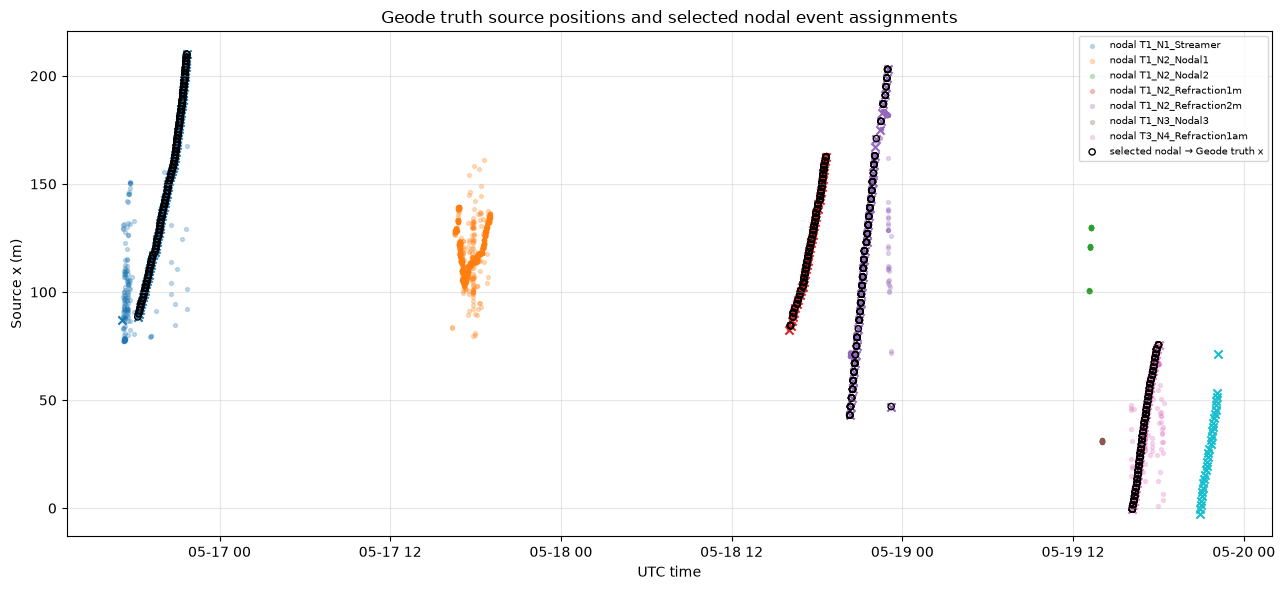

In [10]:
TIMEWINDOW_COLORS = {
    "T1_N1_Streamer": "#1f77b4",
    "T1_N2_Nodal1": "#ff7f0e",
    "T1_N2_Nodal2": "#2ca02c",
    "T1_N2_Refraction1m": "#d62728",
    "T1_N2_Refraction2m": "#9467bd",
    "T1_N3_Nodal3": "#8c564b",
    "T3_N4_Refraction1am": "#e377c2",
}
SURVEY_COLORS = {
    "T1_streamer_masw": "#1f77b4",
    "T1_1m_refraction": "#d62728",
    "T1_2m_refraction": "#9467bd",
    "T3_1m_refraction": "#e377c2",
    "T1A_streamer_masw": "#bcbd22",
    "T4_1m_refraction": "#17becf",
}
DEFAULT_SERIES_COLOR = "#7f7f7f"

fig, ax = plt.subplots(figsize=(13, 6))
for label, subset in nodal_use.dropna(subset=["estimated_source_x_m"]).groupby("timewindow_label"):
    ax.scatter(subset["event_time_dt"], subset["estimated_source_x_m"], s=8, alpha=0.25,
               color=TIMEWINDOW_COLORS.get(str(label), DEFAULT_SERIES_COLOR), label=f"nodal {label}")

for _, geode in geode_use.iterrows():
    color = TIMEWINDOW_COLORS.get(
        str(geode.get("nodal_timewindow_label")),
        SURVEY_COLORS.get(str(geode.get("survey")), DEFAULT_SERIES_COLOR),
    )
    ax.hlines(geode["source_x_m"], geode["stack_start_dt"], geode["stack_end_dt"],
              linewidth=2, alpha=0.8, color=color)
    if pd.notna(geode.get("geode_final_trigger_time_dt", pd.NaT)):
        ax.scatter([geode["geode_final_trigger_time_dt"]], [geode["source_x_m"]],
                   marker="x", s=35, color=color)

if len(accepted_matches):
    accepted_plot = accepted_matches.copy()
    accepted_plot["nodal_dt"] = pd.to_datetime(accepted_plot["nodal_event_time_utc"], utc=True)
    ax.scatter(accepted_plot["nodal_dt"], accepted_plot["source_x_truth_m"], s=20, marker="o",
               facecolors="none", edgecolors="black", label="selected nodal → Geode truth x")

ax.set_title("Geode truth source positions and selected nodal event assignments")
ax.set_xlabel("UTC time")
ax.set_ylabel("Source x (m)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## 11. Focused survey summaries

In [11]:
if len(stack_summary):
    display(stack_summary.groupby("geode_survey", dropna=False).agg(
        n_stacks=("geode_event_id", "count"),
        total_candidates=("n_candidate_events", "sum"),
        total_auto_accepted=("n_accepted_auto", "sum"),
    ).reset_index())

# Examples for focused inspection:
# display(event_catalog[event_catalog["nodal_timewindow_label"].eq("T1_N2_Refraction2m")].head(100))
# display(matches[matches["position_qc_status"].eq("not_applicable_off_end")].head(100))

,geode_survey,n_stacks,total_candidates,total_auto_accepted
0,T1_1m_refraction,39,252,252
1,T1_2m_refraction,39,225,225
2,T1_streamer_masw,82,296,296
3,T3_1m_refraction,39,193,193
